In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [41]:
!ls *.txt

OX359245.1.0D_pi.biallelic_ac.txt OX359248.1.0D_pi.biallelic_ac.txt
OX359245.1.4D_pi.biallelic_ac.txt OX359248.1.4D_pi.biallelic_ac.txt
OX359246.1.0D_pi.biallelic_ac.txt OX359249.1.0D_pi.biallelic_ac.txt
OX359246.1.4D_pi.biallelic_ac.txt OX359249.1.4D_pi.biallelic_ac.txt
OX359247.1.0D_pi.biallelic_ac.txt OX359250.1.0D_pi.biallelic_ac.txt
OX359247.1.4D_pi.biallelic_ac.txt OX359250.1.4D_pi.biallelic_ac.txt


In [3]:
x_chroms = ['OX359249.1.0D_pi.biallelic_ac.txt',
           'OX359249.1.4D_pi.biallelic_ac.txt',
           'OX359250.1.0D_pi.biallelic_ac.txt',
           'OX359250.1.4D_pi.biallelic_ac.txt']

In [110]:
df = pd.read_csv(x_chroms[0], sep='\t')
df['MAC'] = df[['ref_allele_count','alt_allele_count']].min(axis=1)

(0.0, 13.0)

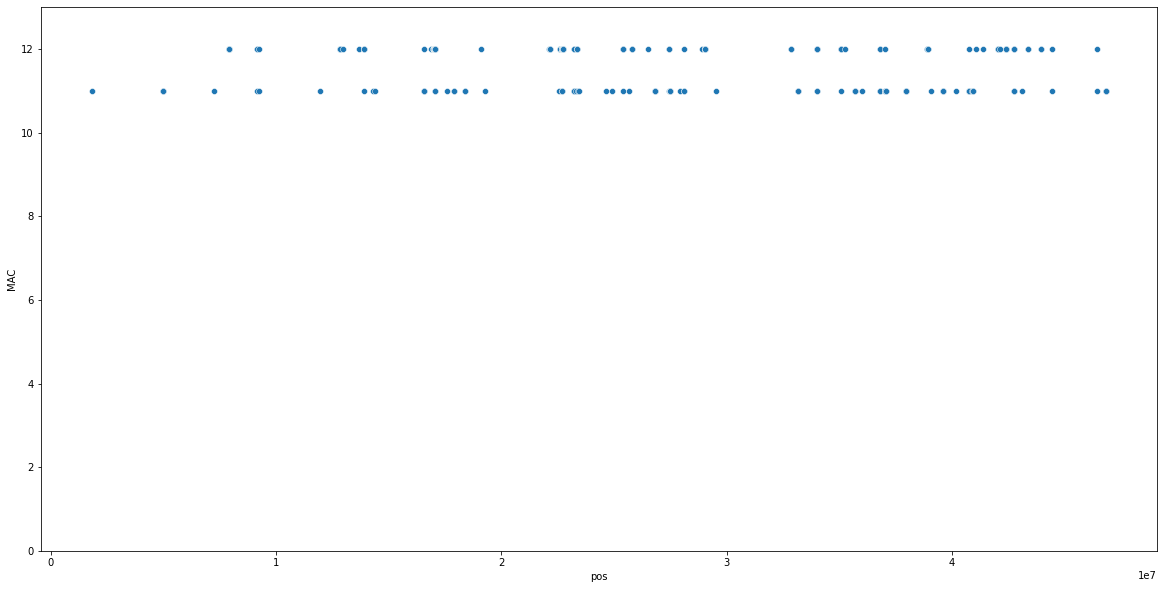

In [88]:
fig, axs = plt.subplots(figsize=[20,10])

sns.scatterplot(data = df[df['MAC']>=11],
            x = 'pos',
            y='MAC',
            ax = axs)

axs.set_ylim(0, 13)

In [126]:
results = []
increment = 1_000_000
for i in range(0, int(df['pos'].max()+increment), increment):
    mean = df[(df['pos']>i) & (df['pos']<i+increment)]['MAC'].mean()
    results.append(np.array((i+(increment/2), mean)))
results = np.array(results)
df2 = pd.DataFrame(results, columns=['midpoint','mean_MAC'])

(0.0, 13.0)

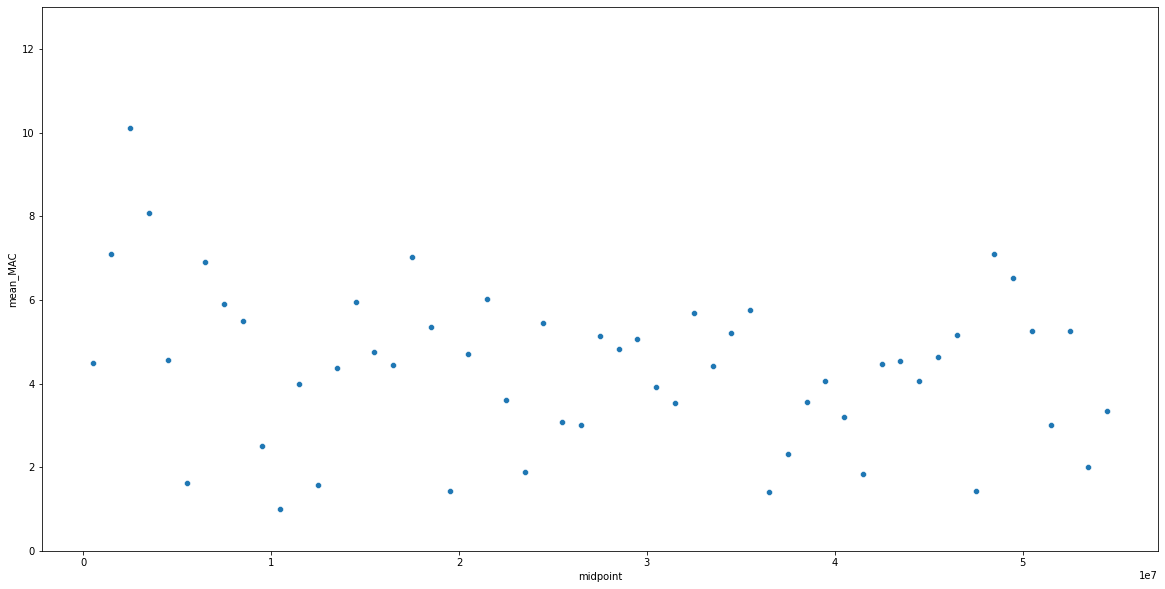

In [127]:
fig, axs = plt.subplots(figsize=[20,10])

sns.scatterplot(data = df2,
            x = 'midpoint',
            y='mean_MAC',
            ax = axs)

axs.set_ylim(0, 13)

In [237]:
df = pd.read_csv(x_chroms[2], sep='\t')
#df = pd.read_csv('OX359246.1.0D_pi.biallelic_ac.txt', sep='\t')

df['MAC'] = df[['ref_allele_count','alt_allele_count']].min(axis=1)

In [238]:
df[(df['MAC']==11)&(df['pos']<5_000_000)].shape[0]
# 35
# 90
# 15
# 56

6

In [244]:
results = []
increment = 500_000
for i in range(0, int(df['pos'].max()+increment), increment):
    count = df[(df['pos']>i) & (df['pos']<i+increment) & (df['MAC']>11)]['MAC'].shape[0]
    results.append(np.array((i+(increment/2), count)))
results = np.array(results)
df2 = pd.DataFrame(results, columns=['midpoint','MAC >= 11 count'])
df2['MAC_prop'] = df2['MAC >= 11 count']/df2['MAC >= 11 count'].sum()

<AxesSubplot:xlabel='midpoint', ylabel='MAC >= 11 count'>

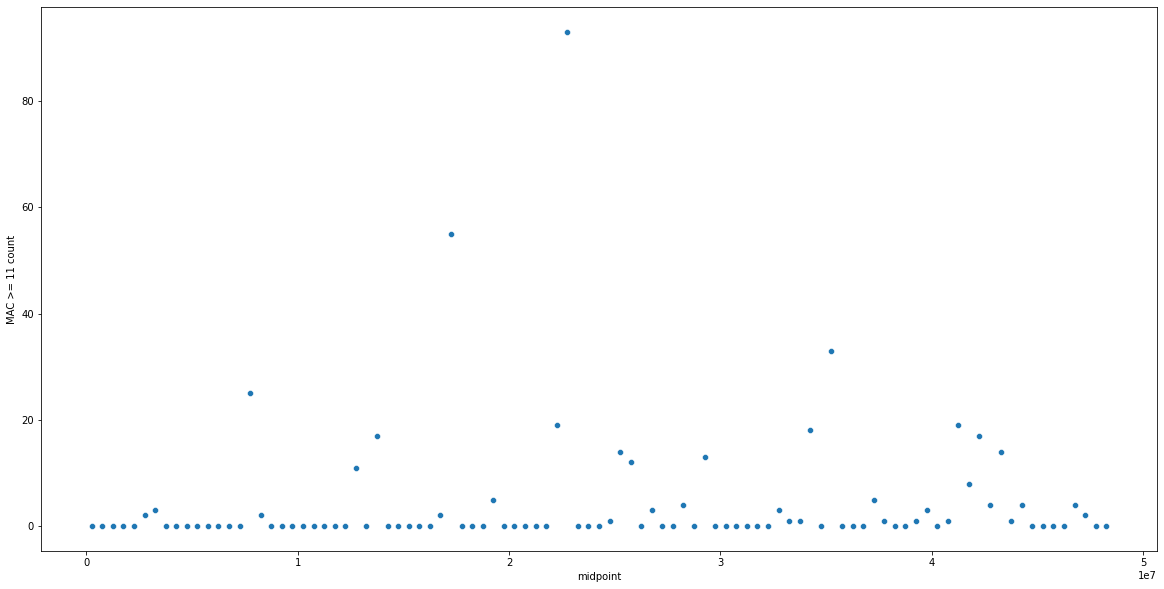

In [245]:
fig, axs = plt.subplots(figsize=[20,10])

sns.scatterplot(data = df2,
            x = 'midpoint',
            y = 'MAC >= 11 count',
            ax = axs)

#axs.set_ylim(0, 13)

<AxesSubplot:xlabel='midpoint', ylabel='MAC_prop'>

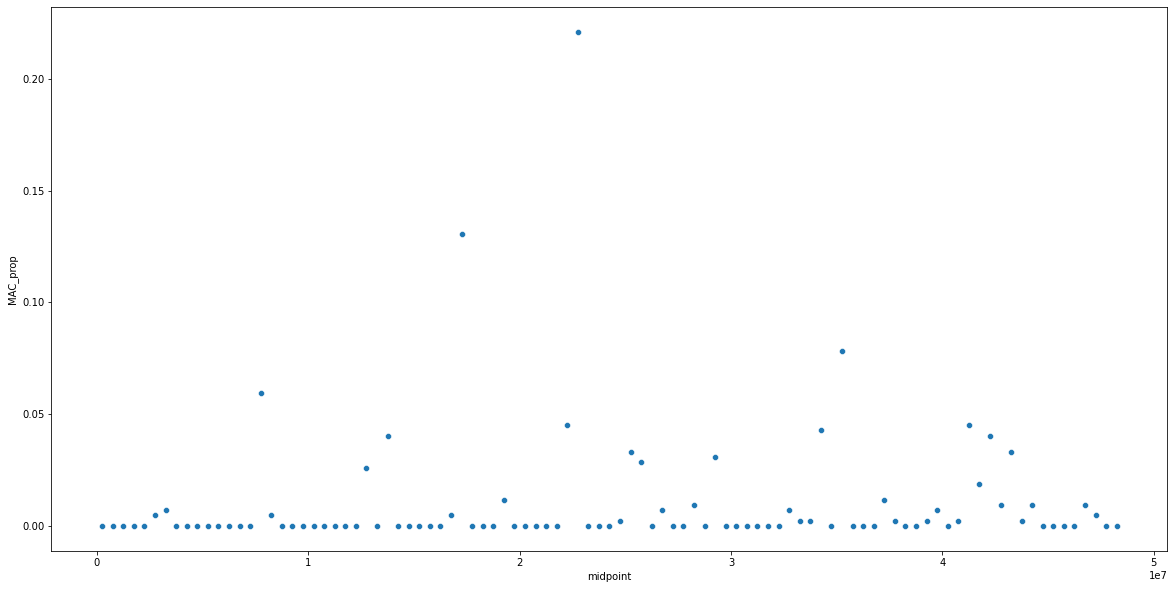

In [246]:
fig, axs = plt.subplots(figsize=[20,10])

sns.scatterplot(data = df2,
            x = 'midpoint',
            y = 'MAC_prop',
            ax = axs)

#axs.set_ylim(0, 13)

In [247]:
df2.sort_values(by=['MAC_prop'])

,midpoint,MAC >= 11 count,MAC_prop
0,250000.0,0.0,0.000000
37,18750000.0,0.0,0.000000
39,19750000.0,0.0,0.000000
40,20250000.0,0.0,0.000000
41,20750000.0,0.0,0.000000
...,...,...,...
44,22250000.0,19.0,0.045131
15,7750000.0,25.0,0.059382
70,35250000.0,33.0,0.078385
34,17250000.0,55.0,0.130641
